# PCA, MDS and t-SNE on SDG 15 Indicators

Progress on SDG 15 can't be measured with one number, so I picked four indicators and mapped them
using three dimensionality reduction methods: PCA, MDS and t-SNE. Part of the goal was learning to
use them.

The point is to compare the methods and their configurations, since they complement each other.
There are ten configurations below.

**Data.** OECD Data Explorer, SDG 15 indicators, drawing on the UN Global SDG Database.
[data-explorer.oecd.org](https://data-explorer.oecd.org/vis?lc=en&tm=sdg%252015).

The four variables per country:

1. Proportion of degraded mountain land, which covers upland ecosystems separately from land in
   general.
2. Proportion of land degraded over total land area, the broad degradation measure.
3. Protected areas as a share of total land, the conservation measure.
4. Red List Index, which measures extinction risk across a country's species. Lower means worse,
   the opposite direction from the other three.

Values are 2015 observations. Sixteen countries reported all four.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from style import use_report_style

use_report_style()

import matplotlib.patches as patches
import plotly.express as px
from adjustText import adjust_text
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, TSNE
from sklearn.preprocessing import StandardScaler

In [2]:
sdg = pd.read_csv("../data/un_sdg15.csv", low_memory=False)
sdg = sdg[["Reference area", "REF_AREA", "SDG series", "TIME_PERIOD", "OBS_VALUE"]]

# One row per country, one column per indicator
wide = (
    sdg.groupby(["Reference area", "REF_AREA", "SDG series"])["OBS_VALUE"]
    .mean()
    .unstack()
    .reset_index()
)

complete = wide.dropna()
print(f"{len(complete)} countries reporting all four indicators")
complete

16 countries reporting all four indicators


SDG series,Reference area,REF_AREA,Proportion of degraded mountain land [Total],Proportion of land that is degraded over total land area,Protected areas as a share of total land,Red List Index
0,Australia,AUS,1.6,7.34,17.03,0.84
4,Chile,CHL,1.6,6.09,15.92,0.78
5,Colombia,COL,3.0,28.80,15.35,0.75
6,Costa Rica,CRI,2.2,33.21,26.13,0.85
7,Czechia,CZE,0.5,3.21,20.53,0.97
10,Finland,FIN,7.3,0.95,13.14,0.99
13,Greece,GRC,3.7,4.77,34.62,0.87
14,Hungary,HUN,0.4,2.29,22.50,0.91
18,Italy,ITA,5.9,14.08,18.15,0.89
24,Mexico,MEX,1.6,56.69,14.07,0.70


## Setting up

Coloring by continent might give interesting information. The continent is only a label and is not used in any of the projections.


In [9]:
VARIABLES = [
    "Proportion of degraded mountain land [Total]",
    "Proportion of land that is degraded over total land area",
    "Protected areas as a share of total land",
    "Red List Index",
]

X = complete[VARIABLES]

continents = px.data.gapminder()[["country", "continent"]].drop_duplicates()

# inner join here drops Czechia
continents["country"] = continents["country"].replace({"Czech Republic": "Czechia"})

meta = (
    complete[["Reference area", "REF_AREA"]]
    .merge(continents, left_on="Reference area", right_on="country", how="inner")
    .reset_index(drop=True)
)

X = X.loc[complete["Reference area"].isin(meta["Reference area"])].reset_index(drop=True)

X.describe().round(2)

SDG series,Proportion of degraded mountain land [Total],Proportion of land that is degraded over total land area,Protected areas as a share of total land,Red List Index
count,16.00,16.00,16.00,16.00
mean,3.32,12.09,24.76,0.86
std,3.02,15.26,9.37,0.10
min,0.40,0.20,13.14,0.66
25%,1.60,3.10,16.75,0.82
50%,2.20,5.63,22.57,0.88
75%,3.72,14.18,33.46,0.93
max,12.30,56.69,40.14,0.99


In [10]:
def draw_projection(ax, coords, caption, legend=False):
    # scatter one projection, colored by continent, labelled with country codes
    projected = meta.copy()
    projected["x"], projected["y"] = coords[:, 0], coords[:, 1]

    sns.scatterplot(
        data=projected, x="x", y="y",
        hue="continent", style="continent",
        s=100, palette="Set1", ax=ax, legend=legend,
    )

    handles = ax.get_legend_handles_labels() if legend else None
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    labels = [
        ax.text(row.x, row.y, row.REF_AREA, fontsize=9, alpha=0.8, fontweight="bold")
        for row in projected.itertuples()
    ]
    adjust_text(labels, ax=ax, arrowprops=dict(arrowstyle="->", color="gray", lw=0.7))

    ax.axis("off")
    ax.text(
        0.5, -0.05, caption, transform=ax.transAxes,
        ha="center", va="top", fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="gray", alpha=0.5),
    )
    ax.add_patch(patches.Rectangle(
        (0, 0), 1, 1, transform=ax.transAxes,
        edgecolor="black", fill=False, clip_on=False,
    ))
    return handles

## PCA: with and without standardization

PCA looks for the direction in which the countries are most spread out and makes that the first axis, then the most spread out direction perpendicular to it and makes that the second. Spread doesn't consider the units, so the Red List Index (going from 0.66 to 0.99) counts for less than degraded land (going from 0.2 to 56.7). That's why I run PCA once with standardization and once without.


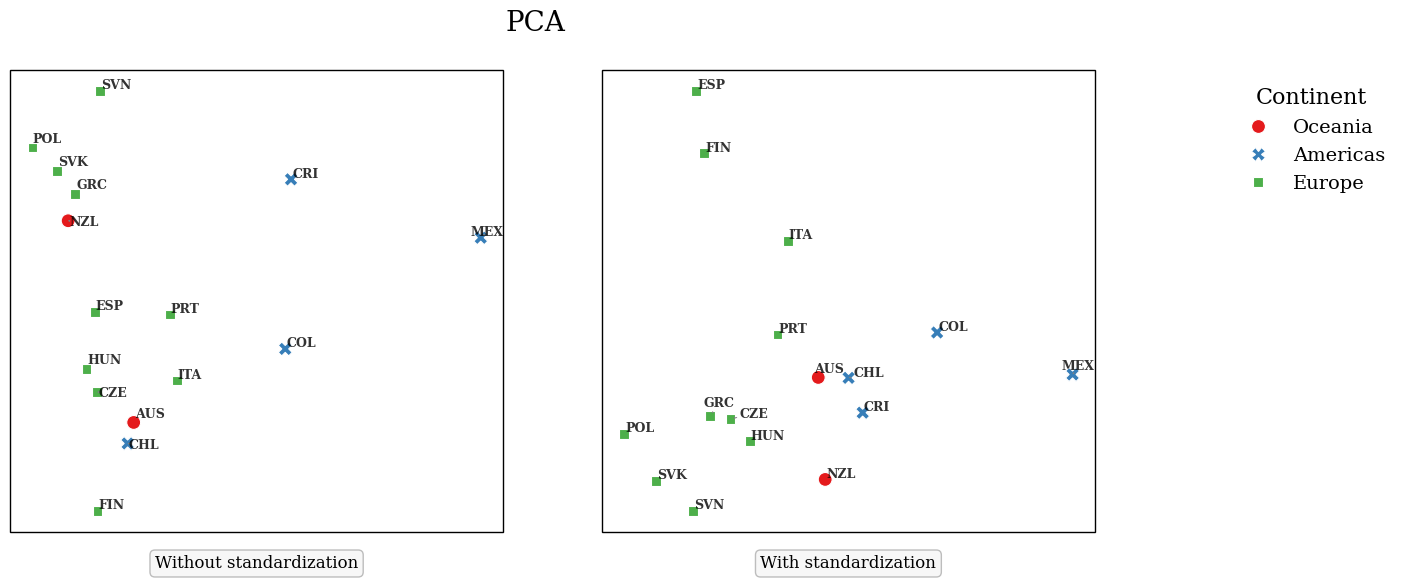

Explained variance ratio
  raw:          [0.762 0.212]
  standardized: [0.458 0.264]


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

raw_pca = PCA(n_components=2).fit(X)
handles = draw_projection(axes[0], raw_pca.transform(X), "Without standardization", legend=True)

scaled = StandardScaler().fit_transform(X)
std_pca = PCA(n_components=2).fit(scaled)
draw_projection(axes[1], std_pca.transform(scaled), "With standardization")

fig.legend(*handles, title="Continent", bbox_to_anchor=(0.99, 0.88),
           loc="upper left", fontsize=14, title_fontsize=16)
plt.suptitle("PCA", fontsize=20)
plt.savefig("../figures/05-pca.png", dpi=150, bbox_inches="tight")
plt.show()

print("Explained variance ratio")
print(f"  raw:          {raw_pca.explained_variance_ratio_.round(3)}")
print(f"  standardized: {std_pca.explained_variance_ratio_.round(3)}")

In [6]:
# How much does each original variable contribute to each component?
loadings = pd.concat(
    {
        "raw": pd.DataFrame(raw_pca.components_.T, columns=["PC1", "PC2"]),
        "standardized": pd.DataFrame(std_pca.components_.T, columns=["PC1", "PC2"]),
    },
    axis=1,
).round(3)
loadings.index = [v[:45] for v in VARIABLES]
loadings

raw        standardized  \
                                                 PC1    PC2          PC1   
Proportion of degraded mountain land [Total]  -0.027 -0.067       -0.204   
Proportion of land that is degraded over tota  0.948  0.314        0.633   
Protected areas as a share of total land      -0.316  0.947       -0.457   
Red List Index                                -0.003 -0.000       -0.591   

                                                      
                                                 PC2  
Proportion of degraded mountain land [Total]   0.853  
Proportion of land that is degraded over tota  0.004  
Protected areas as a share of total land      -0.512  
Red List Index                                 0.105

Raw PC1: 0.948 on degraded land, -0.003 on Red List Index -> raw PC1 is essentially the one variable with the widest range. Standardization fixes this.

Interesting to see that standardized PCA seems to separate the continents on PC1. Not really distance-wise, though.

## MDS: two random seeds

Compared to others, MDS preserves the distances most accurately, so 2D distances match distances in the original space.

MDS starts from a random configuration, so the seeds should be tested.


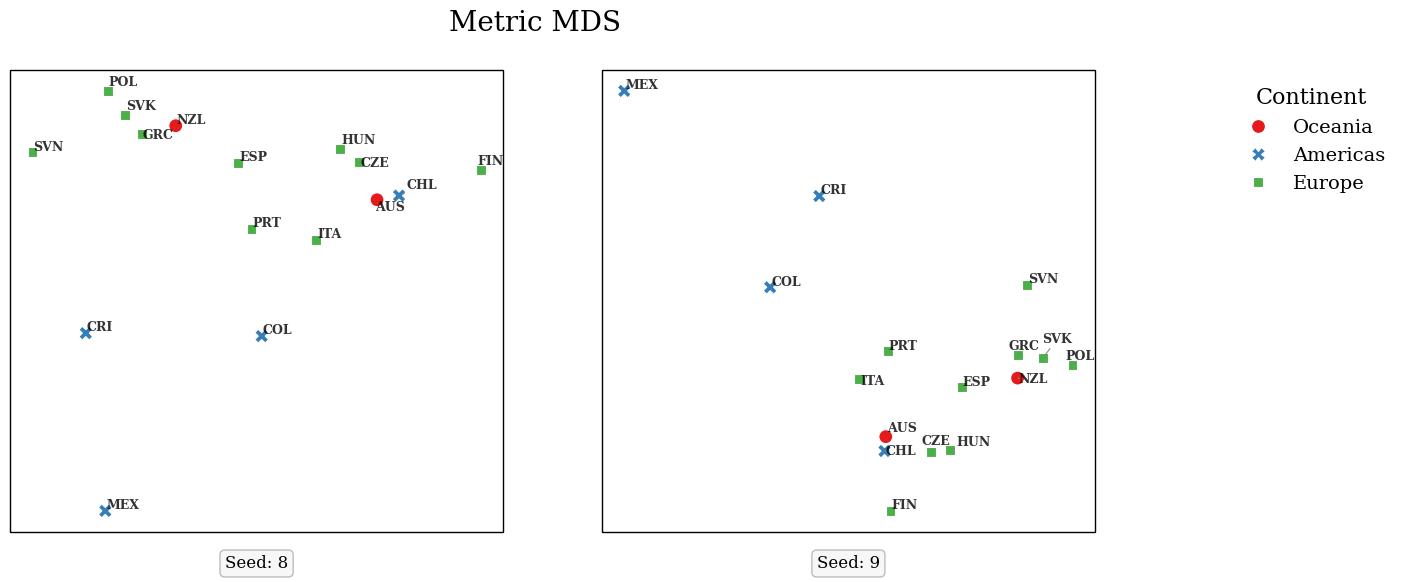

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, seed in zip(axes, [8, 9]):
    mds = MDS(
        n_components=2, max_iter=3000, eps=1e-9, n_init=1,
        random_state=seed, metric="euclidean", init="random", n_jobs=1,
    )
    handles = draw_projection(
        ax, mds.fit_transform(X), f"Seed: {seed}", legend=(seed == 8)
    ) or handles

fig.legend(*handles, title="Continent", bbox_to_anchor=(0.99, 0.88),
           loc="upper left", fontsize=14, title_fontsize=16)
plt.suptitle("Metric MDS", fontsize=20)
plt.savefig("../figures/05-mds.png", dpi=150, bbox_inches="tight")
plt.show()

Changing the seed only rotates the plot and doesn't rearrange it -> distances are what matters and direction is meaningless.


## t-SNE: three perplexities, two seeds each

Compared to others, t-SNE preserves local neighborhoods rather than global distances. The size of that neighborhood is pretty much what perplexity controls. t-SNE is used for larger datasets. With 16 data points, there isn't much local structure to preserve and perplexity becomes very impactful.

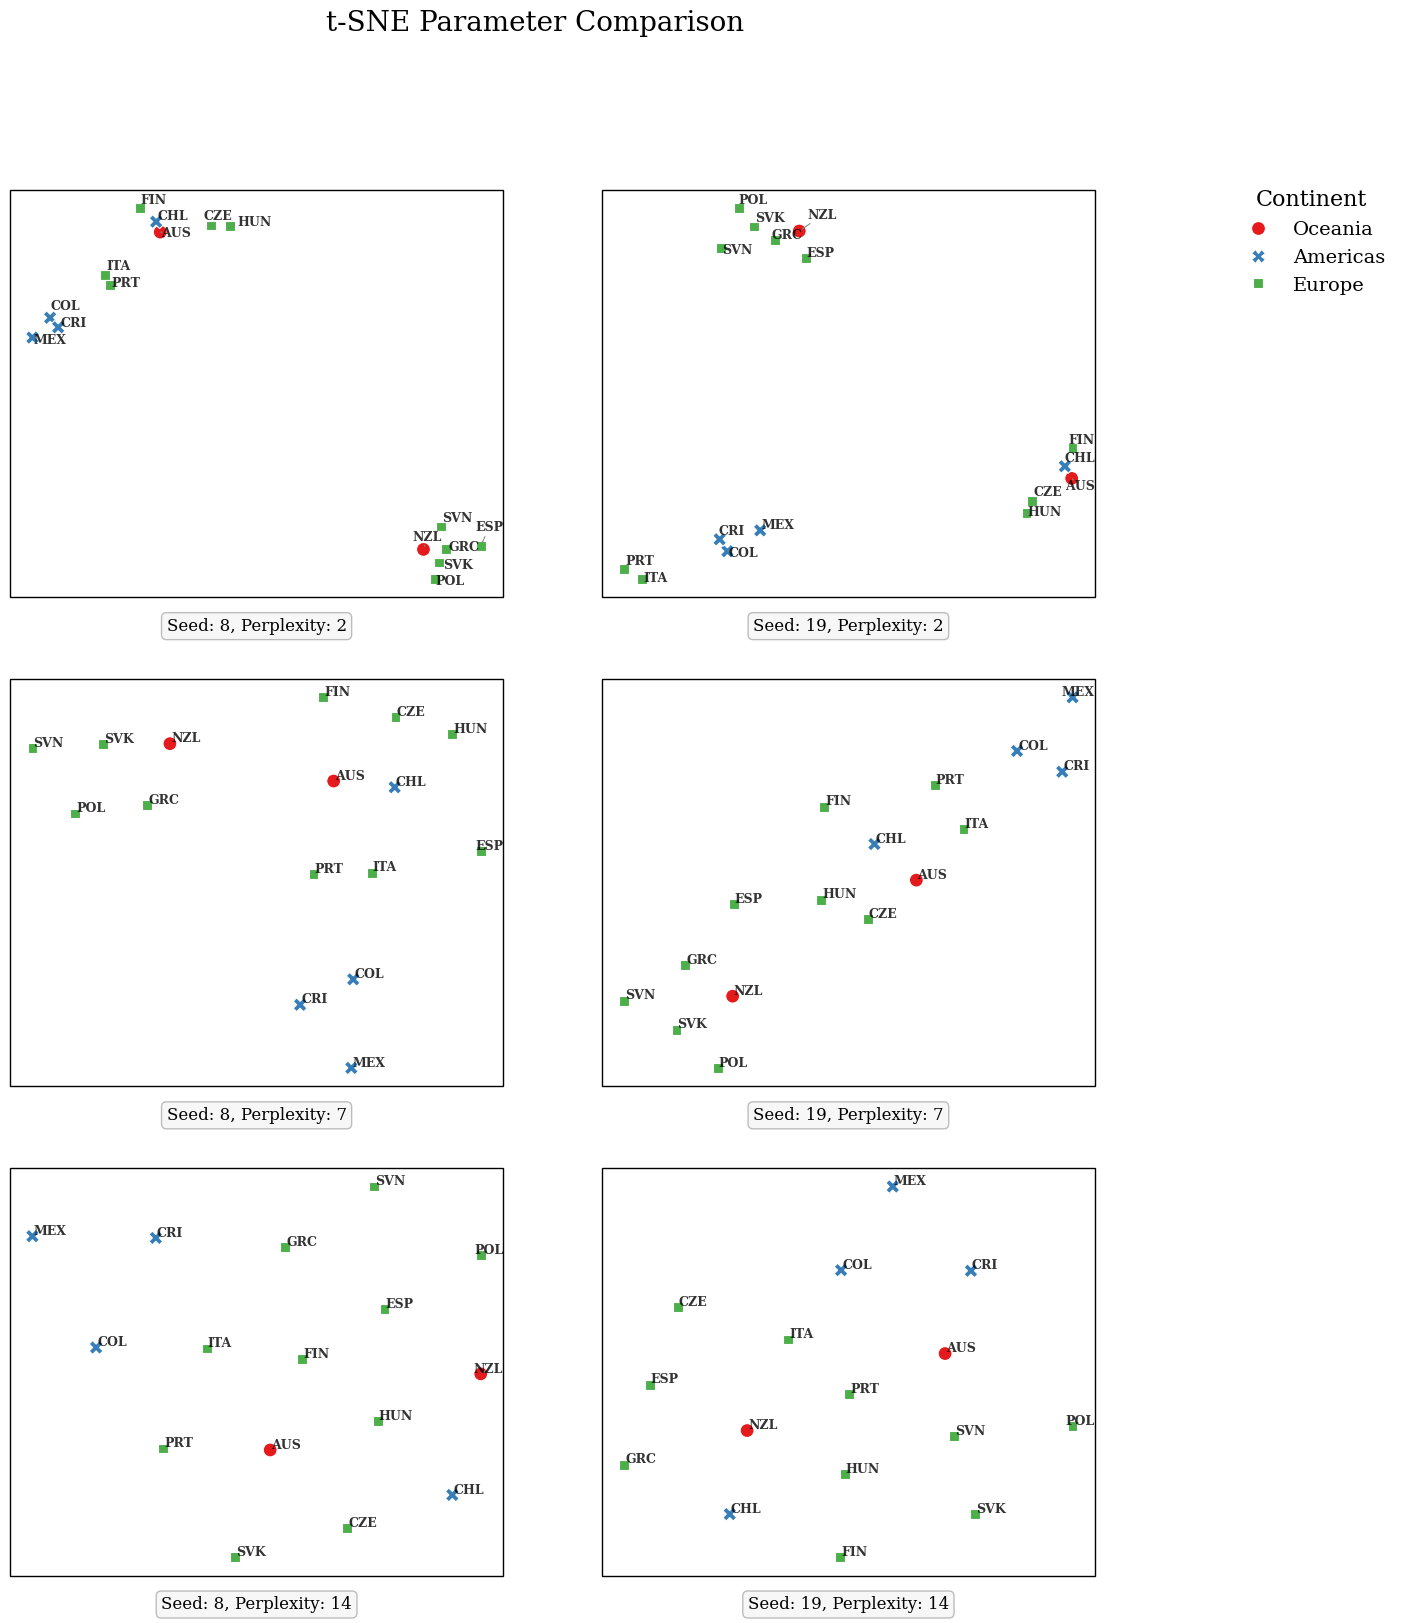

In [8]:
perplexities = [2, 7, 14]
seeds = [8, 19]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
handles = None

for ax, (perplexity, seed) in zip(
    axes.flatten(), [(p, s) for p in perplexities for s in seeds]
):
    tsne = TSNE(
        n_components=2, perplexity=perplexity,
        random_state=seed, metric="euclidean", init="random",
    )
    handles = draw_projection(
        ax, tsne.fit_transform(X),
        f"Seed: {seed}, Perplexity: {perplexity}",
        legend=(handles is None),
    ) or handles

fig.legend(*handles, title="Continent", bbox_to_anchor=(0.99, 0.89),
           loc="upper left", fontsize=14, title_fontsize=16)
plt.suptitle("t-SNE Parameter Comparison", fontsize=20)
plt.savefig("../figures/05-tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## Comparison & results

In each figure, closeness and grouping is related to similarity in the four variables, meaning that countries close to each other most likely share similar nature protection policies and face similar land degradation problems. Nearly every figure supports three conclusions: firstly, the same group of three countries in the Americas – Mexico, Colombia and Costa Rica – always shows up. Overall, Mexico is the most isolated from all countries. Secondly, European and Oceanian countries are clustered together (t-SNE with 2 perplexity is not meaningful in this regard). Finally, Australia and Chile share surprisingly similar SDG 15 profiles despite their geographical distance. One interesting finding is also that standardized PCA separates the continents on principal component 1, even though they don't form groups in the plane.

When comparing the figures, it is clear that they are different aspects of the same things as the relationships between observations stay the same throughout all the figures. A single figure does not provide much information by itself. Therefore, comparing the outputs of different dimensionality reduction methods is necessary for understanding the full picture. In addition, comparing the outputs of one method with different parameters is important as well, especially with t-SNE which changes drastically when its seed and perplexity value change. A low perplexity value in t-SNE forces observations into small groups that do not reflect the real relationships, which may lead to incorrect conclusions especially on different clusters. A higher perplexity value such as 7 or 14 reveals more large-scale relationships and groups. Unlike in MDS where changing the seed only rotates the plot, t-SNE figures can be very different with different seed values, affecting how humans perceive the figure. This means that a certain seed should be preferred if it makes the figure intuitive and visualizes the relationships accurately. 

PCA and MDS follow a similar pattern, the most notable difference being that points in PCA correspond to specific values on two axes while points in MDS have no values and the rotation is meaningless.

**Design notes:**
Displaying country codes became necessary because two Oceanian countries do not represent Oceania, for example. However, displaying the codes was challenging 
as some of the points overlap. I ended up accepting that readability is enough and removing all overlap is not worth the invested time.

Only the second PCA is standardized. The rest use the non-standardized data, which keeps the input the same in every figure. 
